In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete")


Matplotlib is building the font cache; this may take a moment.


Setup complete


In [2]:
carbon_df = pd.read_parquet(DATA_RAW / "carbon_intensity_GB_2021_2024.parquet")
carbon_df["from"] = pd.to_datetime(carbon_df["from"], utc=True)
carbon_df = carbon_df.sort_values("from").reset_index(drop=True)
print("Carbon intensity shape:", carbon_df.shape)
print(carbon_df.dtypes)
carbon_df.head()

Carbon intensity shape: (48237, 5)
from        datetime64[ns, UTC]
to          datetime64[ns, UTC]
forecast                  int64
actual                  float64
index                    object
dtype: object


,from,to,forecast,actual,index
0,2020-12-31 23:30:00+00:00,2021-01-01 00:00:00+00:00,190,184.0,moderate
1,2021-01-01 00:00:00+00:00,2021-01-01 00:30:00+00:00,181,187.0,moderate
2,2021-01-01 00:30:00+00:00,2021-01-01 01:00:00+00:00,178,182.0,moderate
3,2021-01-01 01:00:00+00:00,2021-01-01 01:30:00+00:00,175,178.0,moderate
4,2021-01-01 01:30:00+00:00,2021-01-01 02:00:00+00:00,174,171.0,moderate


In [3]:
gen_df = pd.read_parquet(DATA_RAW / "generation_GB_2021_2024.parquet")
load_df = pd.read_parquet(DATA_RAW / "load_GB_2021_2024.parquet")
print("Generation shape:", gen_df.shape)
print("Load shape:", load_df.shape)
gen_df.head()

Generation shape: (7890, 11)
Load shape: (7886, 1)


,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2021-01-01 00:00:00+00:00,3116.0,11268.0,0.0,0.0,0.0,385.0,5949.0,191.0,0.0,1588.65,3146.04
2021-01-01 00:30:00+00:00,3118.0,11526.0,0.0,0.0,0.0,382.0,5956.0,187.0,1.0,1451.37,3072.82
2021-01-01 01:00:00+00:00,3087.0,11240.0,0.0,0.0,0.0,349.0,5948.0,186.0,1.0,1403.17,3019.87
2021-01-01 01:30:00+00:00,3117.0,10365.0,0.0,0.0,0.0,334.0,5950.0,187.0,0.0,1425.04,2884.78
2021-01-01 02:00:00+00:00,3113.0,10020.0,0.0,0.0,0.0,330.0,5949.0,187.0,0.0,1487.91,2818.44


In [4]:
print("Carbon intensity - missing values:")
print(carbon_df.isnull().sum())
print("\nBasic stats:")
print(carbon_df[["forecast", "actual"]].describe())

Carbon intensity - missing values:
from          0
to            0
forecast      0
actual      187
index         0
dtype: int64

Basic stats:
           forecast        actual
count  48237.000000  48050.000000
mean     173.079545    175.013174
std       63.939642     63.824797
min       23.000000      0.000000
25%      123.000000    125.000000
50%      178.000000    181.000000
75%      224.000000    226.000000
max      380.000000    345.000000


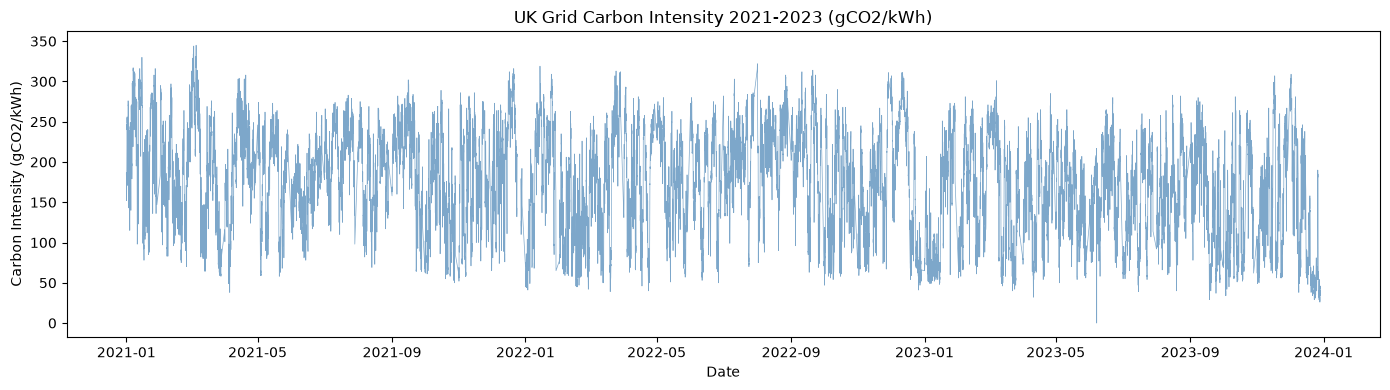

Plot saved


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(carbon_df["from"], carbon_df["actual"], 
        linewidth=0.5, alpha=0.7, color="steelblue")
ax.set_title("UK Grid Carbon Intensity 2021-2023 (gCO2/kWh)")
ax.set_xlabel("Date")
ax.set_ylabel("Carbon Intensity (gCO2/kWh)")
plt.tight_layout()
plt.savefig(FIGURES / "carbon_intensity_timeseries.png", dpi=150)
plt.show()
print("Plot saved")

In [6]:
# Run once elexon_fuelinst_2021_2023.parquet exists
from pathlib import Path
elexon_path = Path("../data/raw/elexon_fuelinst_2021_2023.parquet")
if elexon_path.exists():
    elexon_df = pd.read_parquet(elexon_path)
    print("Elexon shape:", elexon_df.shape)
    print(elexon_df["fuelType"].value_counts())
else:
    print("Elexon not ready yet - rerun once download completes")

Elexon not ready yet - rerun once download completes


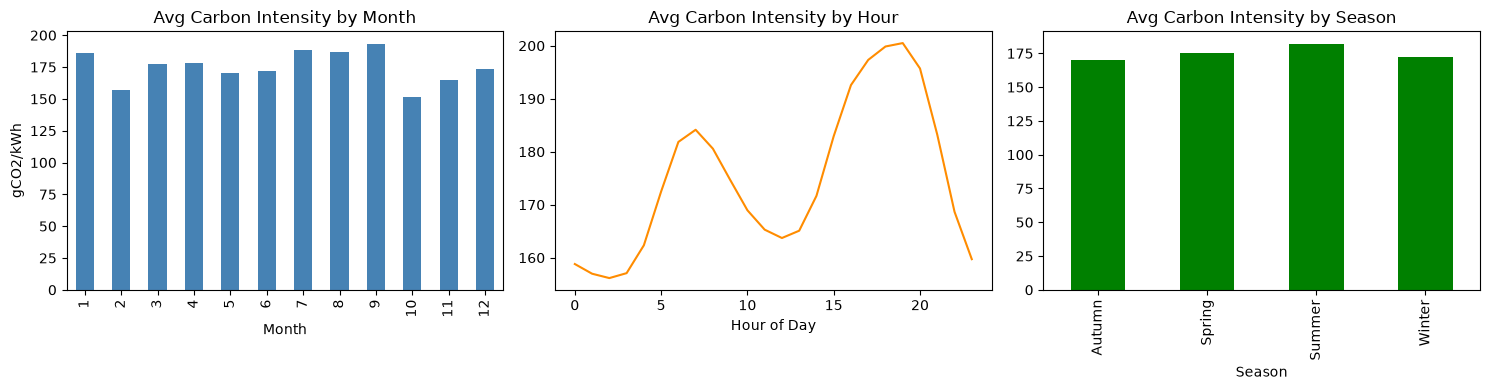

Seasonal plot saved


In [7]:
carbon_df["month"] = carbon_df["from"].dt.month
carbon_df["hour"] = carbon_df["from"].dt.hour
carbon_df["year"] = carbon_df["from"].dt.year
carbon_df["season"] = carbon_df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

carbon_df.groupby("month")["actual"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Avg Carbon Intensity by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("gCO2/kWh")

carbon_df.groupby("hour")["actual"].mean().plot(
    kind="line", ax=axes[1], color="darkorange")
axes[1].set_title("Avg Carbon Intensity by Hour")
axes[1].set_xlabel("Hour of Day")

carbon_df.groupby("season")["actual"].mean().plot(
    kind="bar", ax=axes[2], color="green")
axes[2].set_title("Avg Carbon Intensity by Season")
axes[2].set_xlabel("Season")

plt.tight_layout()
plt.savefig(FIGURES / "carbon_intensity_seasonal.png", dpi=150)
plt.show()
print("Seasonal plot saved")

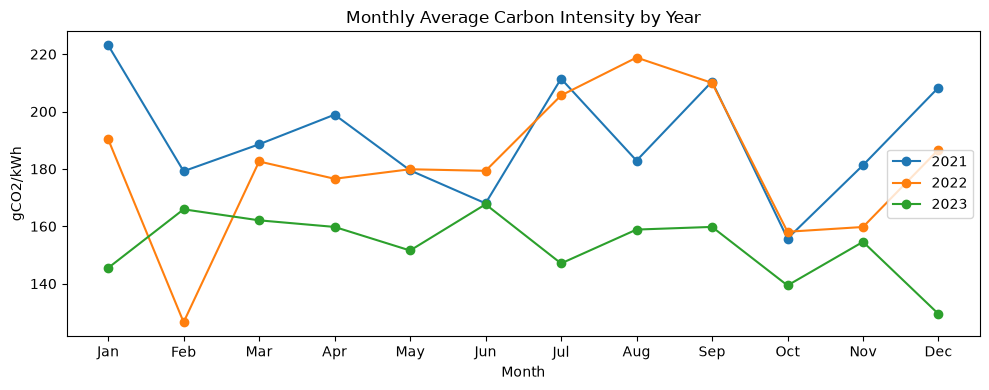

Yearly comparison saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for year in [2021, 2022, 2023]:
    yearly = carbon_df[carbon_df["year"] == year]
    monthly = yearly.groupby("month")["actual"].mean()
    ax.plot(monthly.index, monthly.values, 
            marker="o", label=str(year))

ax.set_title("Monthly Average Carbon Intensity by Year")
ax.set_xlabel("Month")
ax.set_ylabel("gCO2/kWh")
ax.legend()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.savefig(FIGURES / "carbon_intensity_yearly.png", dpi=150)
plt.show()
print("Yearly comparison saved")

In [13]:
import xarray as xr

era5_frames = []
for year in [2021, 2022, 2023]:
    # instant variables - wind and temperature
    ds_instant = xr.open_dataset(
        DATA_RAW / f"era5_{year}/data_stream-oper_stepType-instant.nc"
    )
    # accumulated variables - solar radiation
    ds_accum = xr.open_dataset(
        DATA_RAW / f"era5_{year}/data_stream-oper_stepType-accum.nc"
    )
    
    print(f"ERA5 {year} instant vars:", list(ds_instant.data_vars))
    print(f"ERA5 {year} accum vars:", list(ds_accum.data_vars))
    
    df_instant = pd.DataFrame({
        "datetime": ds_instant["valid_time"].values,
        "u10": ds_instant["u10"].values.mean(axis=(1,2)),
        "t2m": ds_instant["t2m"].values.mean(axis=(1,2)) - 273.15,
    })
    
    df_accum = pd.DataFrame({
        "datetime": ds_accum["valid_time"].values,
        "ssrd": ds_accum["ssrd"].values.mean(axis=(1,2)),
    })
    
    df_year = pd.merge(df_instant, df_accum, on="datetime", how="outer")
    df_year["year"] = year
    era5_frames.append(df_year)
    
    ds_instant.close()
    ds_accum.close()

era5_df = pd.concat(era5_frames, ignore_index=True)
era5_df = era5_df.sort_values("datetime").reset_index(drop=True)
era5_df["datetime"] = pd.to_datetime(era5_df["datetime"], utc=True)
print("\nERA5 combined shape:", era5_df.shape)
print(era5_df.head())

ERA5 2021 instant vars: ['u10', 't2m']
ERA5 2021 accum vars: ['ssrd']
ERA5 2022 instant vars: ['u10', 't2m']
ERA5 2022 accum vars: ['ssrd']
ERA5 2023 instant vars: ['u10', 't2m']
ERA5 2023 accum vars: ['ssrd']

ERA5 combined shape: (2190, 5)
                   datetime       u10       t2m          ssrd  year
0 2021-01-01 00:00:00+00:00 -0.018510  4.468536       0.00000  2021
1 2021-01-01 12:00:00+00:00  0.823902  5.037720  458692.81250  2021
2 2021-01-02 00:00:00+00:00  1.226840  3.972382       0.00000  2021
3 2021-01-02 12:00:00+00:00  0.968933  4.640991  433891.78125  2021
4 2021-01-03 00:00:00+00:00 -1.530687  4.105896       0.00000  2021


In [14]:
# Merge carbon intensity with ERA5 on nearest timestamp
# Carbon intensity is 30-min, ERA5 is 12-hourly - merge on nearest

carbon_df["datetime"] = carbon_df["from"].dt.floor("h")

merged_df = pd.merge_asof(
    carbon_df.sort_values("datetime"),
    era5_df.sort_values("datetime"),
    on="datetime",
    direction="nearest",
    tolerance=pd.Timedelta("12h")
)

print("Merged shape:", merged_df.shape)
print("Missing values after merge:")
print(merged_df.isnull().sum())
merged_df.head()

Merged shape: (48237, 14)
Missing values after merge:
from          0
to            0
forecast      0
actual      187
index         0
month         0
hour          0
year_x        0
season        0
datetime      0
u10           0
t2m           0
ssrd          0
year_y        0
dtype: int64


,from,to,forecast,actual,index,month,hour,year_x,season,datetime,u10,t2m,ssrd,year_y
0,2020-12-31 23:30:00+00:00,2021-01-01 00:00:00+00:00,190,184.0,moderate,12,23,2020,Winter,2020-12-31 23:00:00+00:00,-0.01851,4.468536,0.0,2021
1,2021-01-01 00:00:00+00:00,2021-01-01 00:30:00+00:00,181,187.0,moderate,1,0,2021,Winter,2021-01-01 00:00:00+00:00,-0.01851,4.468536,0.0,2021
2,2021-01-01 00:30:00+00:00,2021-01-01 01:00:00+00:00,178,182.0,moderate,1,0,2021,Winter,2021-01-01 00:00:00+00:00,-0.01851,4.468536,0.0,2021
3,2021-01-01 01:00:00+00:00,2021-01-01 01:30:00+00:00,175,178.0,moderate,1,1,2021,Winter,2021-01-01 01:00:00+00:00,-0.01851,4.468536,0.0,2021
4,2021-01-01 01:30:00+00:00,2021-01-01 02:00:00+00:00,174,171.0,moderate,1,1,2021,Winter,2021-01-01 01:00:00+00:00,-0.01851,4.468536,0.0,2021


In [15]:
# Time features
merged_df["hour"] = merged_df["datetime"].dt.hour
merged_df["day_of_week"] = merged_df["datetime"].dt.dayofweek
merged_df["month"] = merged_df["datetime"].dt.month
merged_df["is_weekend"] = (merged_df["day_of_week"] >= 5).astype(int)
merged_df["season"] = merged_df["month"].map({
    12: 0, 1: 0, 2: 0,   # Winter
    3: 1, 4: 1, 5: 1,    # Spring
    6: 2, 7: 2, 8: 2,    # Summer
    9: 3, 10: 3, 11: 3   # Autumn
})

# Lag features - previous 1h, 2h, 24h carbon intensity
merged_df = merged_df.sort_values("datetime").reset_index(drop=True)
merged_df["actual_lag1"] = merged_df["actual"].shift(2)
merged_df["actual_lag2"] = merged_df["actual"].shift(4)
merged_df["actual_lag24"] = merged_df["actual"].shift(48)

# Rolling mean - 24h average
merged_df["rolling_mean_24h"] = merged_df["actual"].rolling(48).mean()

print("Feature engineered shape:", merged_df.shape)
print("Columns:", list(merged_df.columns))
merged_df.dropna(inplace=True)
print("After dropping NaN rows:", merged_df.shape)

Feature engineered shape: (48237, 20)
Columns: ['from', 'to', 'forecast', 'actual', 'index', 'month', 'hour', 'year_x', 'season', 'datetime', 'u10', 't2m', 'ssrd', 'year_y', 'day_of_week', 'is_weekend', 'actual_lag1', 'actual_lag2', 'actual_lag24', 'rolling_mean_24h']
After dropping NaN rows: (47762, 20)


In [16]:
# Select final feature columns
feature_cols = [
    "datetime", "actual", "forecast",
    "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month", 
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]

final_df = merged_df[feature_cols].copy()
final_df.to_parquet(DATA_PROCESSED / "master_dataset.parquet")
print("Master dataset saved:", final_df.shape)
print(final_df.describe())

Master dataset saved: (47762, 15)
             actual      forecast           u10           t2m          ssrd  \
count  47762.000000  47762.000000  47762.000000  47762.000000  4.776200e+04   
mean     174.726247    172.613772      1.582419     10.637388  6.546644e+05   
std       63.779693     63.782457      3.533232      3.894844  8.207885e+05   
min        0.000000     23.000000     -9.117667      0.778564  0.000000e+00   
25%      125.000000    122.000000     -0.884036      7.567169  0.000000e+00   
50%      180.000000    178.000000      1.493456     10.393005  1.044131e+05   
75%      226.000000    224.000000      3.944972     13.950958  1.304776e+06   
max      345.000000    380.000000     12.468382     20.774658  2.874670e+06   

               hour   day_of_week         month    is_weekend        season  \
count  47762.000000  47762.000000  47762.000000  47762.000000  47762.000000   
mean      11.498890      2.983062      6.483983      0.281563      1.512562   
std        6.9214

In [19]:
# Load Elexon and pivot fuel types into columns
elexon_df["settlementDate"] = pd.to_datetime(elexon_df["settlementDate"], utc=True)

# Create datetime from settlement date + period (each period = 30 mins)
elexon_df["datetime"] = elexon_df["settlementDate"] + pd.to_timedelta(
    (elexon_df["settlementPeriod"] - 1) * 30, unit="min"
)

# Pivot fuel types into columns
elexon_pivot = elexon_df.pivot_table(
    index="datetime",
    columns="fuelType",
    values="generation",
    aggfunc="mean"
).reset_index()

elexon_pivot.columns.name = None
elexon_pivot["datetime"] = pd.to_datetime(elexon_pivot["datetime"], utc=True)

print("Elexon pivoted shape:", elexon_pivot.shape)
print("Fuel type columns:", list(elexon_pivot.columns))
elexon_pivot.head()

Elexon pivoted shape: (42, 21)
Fuel type columns: ['datetime', 'BIOMASS', 'CCGT', 'COAL', 'INTELEC', 'INTEW', 'INTFR', 'INTGRNL', 'INTIFA2', 'INTIRL', 'INTNED', 'INTNEM', 'INTNSL', 'INTVKL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'OIL', 'OTHER', 'PS', 'WIND']


,datetime,BIOMASS,CCGT,COAL,INTELEC,INTEW,INTFR,INTGRNL,INTIFA2,INTIRL,...,INTNEM,INTNSL,INTVKL,NPSHYD,NUCLEAR,OCGT,OIL,OTHER,PS,WIND
0,2026-07-09 00:00:00+00:00,1997.833333,14148.000000,0.0,610.333333,-531.0,1541.666667,0.0,664.833333,-452.0,...,-136.666667,1395.0,1117.666667,479.833333,3004.666667,0.166667,0.0,122.166667,-8.0,1894.166667
1,2026-07-09 00:30:00+00:00,1999.666667,14176.500000,0.0,613.833333,-531.0,1524.166667,0.0,667.666667,-453.0,...,-137.166667,1395.0,1098.833333,337.000000,2997.666667,0.000000,0.0,271.833333,-8.0,1795.333333
2,2026-07-09 01:00:00+00:00,1995.166667,13986.000000,0.0,663.833333,-531.0,1654.666667,0.0,678.666667,-453.0,...,-308.833333,1395.0,984.333333,306.833333,3003.500000,0.000000,0.0,179.166667,-6.0,1665.500000
3,2026-07-09 01:30:00+00:00,1991.833333,13991.666667,0.0,666.666667,-531.0,1663.500000,0.0,684.500000,-453.0,...,-310.000000,1395.0,955.500000,304.833333,2999.166667,0.000000,0.0,150.166667,-3.0,1584.666667
4,2026-07-09 02:00:00+00:00,1992.500000,13462.166667,0.0,684.166667,-531.0,1752.500000,0.0,815.000000,-453.0,...,-351.000000,1395.0,426.500000,304.000000,3001.000000,0.000000,0.0,138.666667,-3.0,1642.833333


In [18]:
from pathlib import Path
elexon_path = Path("../data/raw/elexon_fuelinst_2021_2023.parquet")
if elexon_path.exists():
    elexon_df = pd.read_parquet(elexon_path)
    print("Elexon shape:", elexon_df.shape)
    print(elexon_df["fuelType"].value_counts())

Elexon shape: (5414080, 7)
fuelType
BIOMASS    270704
CCGT       270704
PS         270704
OTHER      270704
OIL        270704
OCGT       270704
NUCLEAR    270704
NPSHYD     270704
INTVKL     270704
INTNSL     270704
INTNEM     270704
INTNED     270704
INTIRL     270704
INTIFA2    270704
INTGRNL    270704
INTFR      270704
INTEW      270704
INTELEC    270704
COAL       270704
WIND       270704
Name: count, dtype: int64
